In [1]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [5]:
from pathlib import Path
import os
# from dotenv import load_dotenv
# load_dotenv()

from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/data/council.txt")
text = DATA_PATH.read_text(encoding="utf-8")

# GraphRAG

In [7]:
# RAG : text -> 청킹 -> 임베딩 -> 벡터스토어 -> 쿼리 -> top-k -> 컨텍스트 활용 -> llm -> 답변

# BM25 등의 hybrid search
# re-ranking
# 쿼리 rewriting

In [8]:
# 그래프 RAG의 경우
# Graph : entity, relation

### Naive RAG에서는 어떻게 청킹, RAG를 구성했었는지 확인

In [10]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 300, chunk_overlap = 50, separators = ['\n\n', '\n', '. ', ' ',''])

In [11]:
demo = splitter.split_text(text)

In [12]:
demo

['제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.',
 '제목: 타즈렌 연구소\n타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.',
 '제목: 할렌 프로토콜\n할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.',
 '제목: 브렌술 아카데미\n브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 북부 어촌 마을의 옛 수도원 부지에서 설립되었다. 브렌술의 현재 학장은 탈라미르 헤쉬로, 1978 년부터 이 기관에 몸담아 왔다. 헤쉬 체제의 브렌술은 매년 소수의 박사후 연구원을 받아 10 년 단위의 장기 프로젝트에 투입하는 전통을 유지하고 있으며, 이 전통이 헤쉬의 학술적

In [14]:
for item in demo:
  print(item)
  print()

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.

제목: 타즈렌 연구소
타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.

제목: 할렌 프로토콜
할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.

제목: 브렌술 아카데미
브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 북부 어촌 마을의 옛 수도원 부지에서 설립되었다. 브렌술의 현재 학장은 탈라미르 헤쉬로, 1978 년부터 이 기관에 몸담아 왔다. 헤쉬 체제의 브렌술은 매년 소수의 박사후 연구원을 받아 10 년 단위의 장기 프로젝트에 투입하는 전통을 유지하고 있으며, 이 전통이 헤쉬의 학술적 명성을 유지하는 바탕이 되

In [16]:
v1 = embeddings.embed_query('노라셋의 공명 하드웨어')

In [18]:
v1[:10]

[-0.02227783203125,
 0.0020008087158203125,
 -0.0016384124755859375,
 -0.0276336669921875,
 0.014495849609375,
 -0.06640625,
 -0.05059814453125,
 0.0250091552734375,
 -0.055419921875,
 -0.05352783203125]

In [19]:
v2 = embeddings.embed_query('노라셋 엔지니어링 그룹이 설계하고 제작하는 주력 제품은 공명 기반의 연산 하드웨어이다. ')

In [20]:
v2[:10]

[0.008544921875,
 0.039520263671875,
 -0.0239105224609375,
 -0.0150146484375,
 0.03765869140625,
 -0.0133056640625,
 -0.0196075439453125,
 0.04571533203125,
 0.01039886474609375,
 -0.0802001953125]

In [21]:
import numpy as np

In [22]:
def cos(x, y):
  return float(x @ y / (np.linalg.norm(x)*np.linalg.norm(y)))

In [23]:
cos(np.array(v1), np.array(v2))

0.6646356187387616

In [24]:
mini_vs = FAISS.from_texts(['오브루리 축제는 매년 늦가을에 눌마리 섬에서 사흘 동안 열리는 문화 축제이다. 섬 전역의 연구자와 학생들이 모여 포스터를 발표하고, 새 아키텍처를 토론하고, 각자의 프로토콜 경험을 공유하는 자리이다. 눌마리 연구 위원회의 위원들은 매년 축제 폐회식에 참석해 다음 해 연구 방향을 짧게 발표하는 전통이 있다.'], embeddings)

In [25]:
mini_vs.similarity_search('오브루리 축제', k = 1)

[Document(id='96779b25-0792-4477-8a12-e4c254b4afc1', metadata={}, page_content='오브루리 축제는 매년 늦가을에 눌마리 섬에서 사흘 동안 열리는 문화 축제이다. 섬 전역의 연구자와 학생들이 모여 포스터를 발표하고, 새 아키텍처를 토론하고, 각자의 프로토콜 경험을 공유하는 자리이다. 눌마리 연구 위원회의 위원들은 매년 축제 폐회식에 참석해 다음 해 연구 방향을 짧게 발표하는 전통이 있다.')]

In [33]:
def build_vector_store(chunks: list[str]) -> FAISS:
    return FAISS.from_texts(chunks, embeddings)

In [34]:
chunks = demo

In [35]:
vs = build_vector_store(chunks)

In [41]:
test = vs.similarity_search_with_score('콰빅스', k = 3)

In [42]:
for doc, dist in test:
  print(f"{dist} : {doc.page_content}")

1.0205005407333374 : 제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.
1.42225182056427 : 제목: 눌마리 연구 위원회
눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모든 지원금 수혜 조건으로 할렌 프로토콜 사용을 요구하며, 매년 가을에 눌마리 연구 활동의 연간 리뷰를 발간하여 지난 한 해의 기관별 성과를 공개적으로 기록한다.
1.4721624851226807 : 제목: 오브루리 축제
오브루리 축제는 매년 늦가을에 눌마리 섬에서 사흘 동안 열리는 문화 축제이다. 섬 전역의 연구자와 학생들이 모여 포스터를 발표하고, 새 아키텍처를 토론하고, 각자의 프로토콜 경험을 공유하는 자리이다. 눌마리 연구 위원회의 위원들은 매년 축제 폐회식에 참석해 다음 해 연구 방향을 짧게 발표하는 전통이 있다.


In [43]:
def retrieve(query, vs, k):
  return [d.page_content for d in vs.similarity_search(query, k=k)]

In [44]:
sample = retrieve('콰빅스 연구소 설립자', vs, k=3)
for i, c in enumerate(sample):
  print(f"\n[{i}] {c[:100]}")


[0] 제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으

[1] 제목: 코바쉬 연구소
코바쉬 연구소는 북부 눌마리의 사설 AI 연구소로, 2001 년에 설립되었고 현재는 옌라 톨름이 소장을 맡고 있다. 코바쉬의 대표 아키텍처인 발레미르 엔진은 

[2] 제목: 눌마리 연구 위원회
눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모


In [47]:
def naive_rag(question, vs, k=3):
    docs = vs.similarity_search(question, k=k)
    context = "\n\n".join([doc.page_content for doc in docs])

    msg = llm.invoke([
        SystemMessage(content="컨텍스트에 근거해 답변하세요."),
        HumanMessage(content=f"""
        - 컨텍스트: {context}
        - 질문: {question}"""
        )
    ])

    return msg.content

In [48]:
naive_rag('코바쉬가 어디에있어', vs)

'코바쉬 연구소는 북부 눌마리에 위치하고 있습니다.'

In [49]:
chunk_list = retrieve('콰빅스 연구소를 지은 사람은 누구인가요?', vs, k=3)

In [50]:
chunk_list

['제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.',
 '제목: 눌마리 연구 위원회\n눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모든 지원금 수혜 조건으로 할렌 프로토콜 사용을 요구하며, 매년 가을에 눌마리 연구 활동의 연간 리뷰를 발간하여 지난 한 해의 기관별 성과를 공개적으로 기록한다.',
 '제목: 코바쉬 연구소\n코바쉬 연구소는 북부 눌마리의 사설 AI 연구소로, 2001 년에 설립되었고 현재는 옌라 톨름이 소장을 맡고 있다. 코바쉬의 대표 아키텍처인 발레미르 엔진은 상업 배포 시장에서 타즈렌의 드리파와 직접 경쟁하는 위치에 있다. 톨름은 파리타 대학교에서 박사 과정을 마쳤으며, 그 시기의 지도 교수는 당시 파리타의 학장이기도 했던 레하즈 콜노였다.']

In [51]:
# 핵심 단어 포함여부 확인 함수
def question_contains_answer(chunks, key):
  return any(key in c for c in chunks)

In [52]:
question_contains_answer(chunk_list, '모리카이')

True

In [53]:
# Multi-hop question
# 여러 단계를 거쳐 답변하는 것
  # 예를 들어 모리카이의 멘토가 쓴 논문은 무엇인가요?
  # 모리카이센 멘토 -> 탈라미르 헤쉬
  # 탈라미르 헤쉬 -> 논문

In [54]:
naive_rag('모리카이 센의 멘토가 쓴 논문은 무엇인가요?', vs, 3) # 그냥 하면 없다고 나옴 (정답: '공명 프레임에 관하여')

'모리카이 센의 멘토인 탈라미르 헤쉬가 쓴 논문은 구체적으로 언급되지 않았습니다. 다만, 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였으며, 센의 박사 학위 지도 교수로 등재되어 있습니다. 따라서 헤쉬가 쓴 논문은 센의 초기 논문과 관련이 있을 가능성이 높습니다.'

In [55]:
retrieve('모리카이 센의 멘토가 쓴 논문은 무엇인가요?', vs, 3) # 못가져왔음

['제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.',
 '제목: 할렌 프로토콜\n할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.',
 '제목: 눌마리 연구 위원회\n눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모든 지원금 수혜 조건으로 할렌 프로토콜 사용을 요구하며, 매년 가을에 눌마리 연구 활동의 연간 리뷰를 발간하여 지난 한 해의 기관별 성과를 공개적으로 기록한다.']

In [62]:
def multihop_diagnosis(question, vs, key, k=5):
    chunks = retrieve(question, vs, k=k)
    answer = naive_rag(question, vs, k=k)

    return {
        "key_in_chunks": any(key in c for c in chunks),
        "key_in_answers": key in answer,
        "answer": answer
    }

In [63]:
multihop_diagnosis('모리카이 센의 멘토가 쓴 논문은 무엇인가요?',vs, '멘토')

{'key_in_chunks': True,
 'key_in_answers': True,
 'answer': '모리카이 센의 멘토인 탈라미르 헤쉬가 쓴 논문은 "공명 프레임에 관하여"입니다.'}

In [64]:
multihop_diagnosis('모리카이 센의 멘토가 쓴 논문은 무엇인가요?',vs, '공명 프레임', k=5)

{'key_in_chunks': True,
 'key_in_answers': True,
 'answer': '모리카이 센의 멘토인 탈라미르 헤쉬가 쓴 논문은 "공명 프레임에 관하여"입니다. 이 논문은 브렌술 아카데미에서 가장 많이 인용된 논문 중 하나이며, 원본 벨트란 설계 문서의 참고 문헌 첫 줄에 기록되어 있습니다.'}

In [65]:
# def global_diagnosis(vs, k=5):
#   institutions = ['콰빅스', '타즈렌', '브렌술']

In [66]:
for de in chunks:
  print(de)
  print()

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.

제목: 타즈렌 연구소
타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.

제목: 할렌 프로토콜
할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.

제목: 브렌술 아카데미
브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 북부 어촌 마을의 옛 수도원 부지에서 설립되었다. 브렌술의 현재 학장은 탈라미르 헤쉬로, 1978 년부터 이 기관에 몸담아 왔다. 헤쉬 체제의 브렌술은 매년 소수의 박사후 연구원을 받아 10 년 단위의 장기 프로젝트에 투입하는 전통을 유지하고 있으며, 이 전통이 헤쉬의 학술적 명성을 유지하는 바탕이 되

## GraphRAG 시작

In [67]:
!pip install networkx

In [68]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import font_manager
# 한글 폰트 (시스템에 따라 다름)
for f in ["NanumGothic", "Noto Sans CJK KR", "AppleGothic", "Malgun Gothic"]:
    if any(f in fn.name for fn in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = f; break
plt.rcParams["axes.unicode_minus"] = False

In [69]:
print(chunks[0])

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.


In [70]:
# 그래프는 entity와 relation

In [82]:
# node
# edge
G_demo = nx.DiGraph() # Di는 Directional

G_demo.add_node('모리카이 센', type = 'Person')
G_demo.add_node('콰빅스 연구소', type = 'Organization')
G_demo.add_node('브렌술 아카테미', type = 'Organization')
G_demo.add_node('탈라미르 헤쉬', type = 'Person')
G_demo.add_node('벨트란 사고 엔진', type = 'Product')

G_demo.add_edge('모리카이 센', '콰빅스 연구소', relation = 'founded', year = 1987)
G_demo.add_edge('모리카이 센', '탈라미르 헤쉬', relation = 'mentor_of')
G_demo.add_edge('모리카이 센', '브렌술 아카테미', relation = 'postdoc_at')
G_demo.add_edge('탈라미르 헤쉬', '브렌술 아카테미', relation = 'founded')
G_demo.add_edge('콰빅스 연구소', '벨트란 사고 엔진', relation = 'developed')


In [79]:
G_demo.number_of_nodes(), G_demo.number_of_edges()

(5, 5)

In [73]:
G_demo.nodes(data = True)

NodeDataView({'모리카이 센': {'type': 'Person'}, '콰빅스 연구소': {'type': 'Organization'}})

In [74]:
G_demo.edges(data=True)

OutEdgeDataView([('모리카이 센', '콰빅스 연구소', {'relation': 'founded'})])

In [80]:
for u, v, d in G_demo.edges(data = True):
  print(f" ({u}) -- {d['relation']} --> ({v})")

 (모리카이 센) -- founded --> (콰빅스 연구소)
 (모리카이 센) -- mentor_of --> (탈라미르 헤쉬)
 (모리카이 센) -- postdoc_at --> (브렌술 아카테미)
 (콰빅스 연구소) -- developed --> (벨트란 사고 엔진)
 (탈라미르 헤쉬) -- founded --> (브렌술 아카테미)


In [85]:
def visualize_kg(G, title=""):
  color_map = {"Person": "#FFB347", "Organization": "#77DD77", "Product": "#AEC6CF"}
  pos = nx.spring_layout(G, seed = 42)
  colors = [color_map.get(G.nodes[n].get('type', ''), '#CCCCCC') for n in G.nodes]
  plt.figure(figsize = (10, 7))
  nx.draw(G, pos, node_color = colors, with_labels = True, node_size = 2400, font_size = 10, font_family = plt.rcParams.get('font.family', 'sans-serif'),
          arrowsize = 20, edge_color = 'gray'
          )
  edge_labels = {(u, v): d.get('relation', '') for u, v, d in G.edges(data= True)} # {('모리카이센', '콰빅스연구소'): 'founded'...}
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
  plt.title(title)
  plt.axis('off')
  plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53104 (\N{HANGUL SYLLABLE KWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48709 (\N{HANGUL SYLLABLE BIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

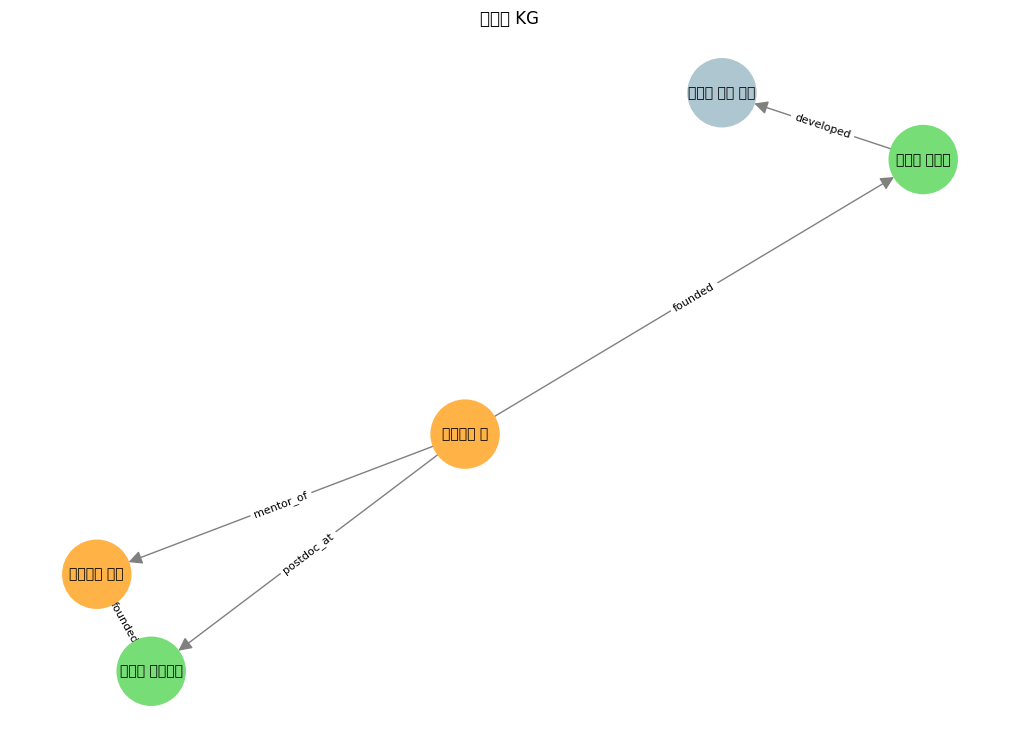

In [86]:
visualize_kg(G_demo, '콰빅스 KG')

In [89]:
list(G_demo.successors('모리카이 센')) # 모리카이 센에서 나가는 것들

['콰빅스 연구소', '탈라미르 헤쉬', '브렌술 아카테미']

In [90]:
G_demo['모리카이 센']

AtlasView({'콰빅스 연구소': {'relation': 'founded', 'year': 1987}, '탈라미르 헤쉬': {'relation': 'mentor_of'}, '브렌술 아카테미': {'relation': 'postdoc_at'}})

In [93]:
def neighbors_with_labels(G, node):
  out = []
  for v in G.successors(node):
    out.append({'direction' : 'out', 'relation' : G[node][v].get('relation', ''), 'neighbor': v})
  for u in G.predecessors(node):
    out.append({'direction': 'in', 'relation': G[u][node].get('relation', ''), 'neighbor' : u})
  return out

In [94]:
neighbors_with_labels(G_demo, '모리카이 센')

[{'direction': 'out', 'relation': 'founded', 'neighbor': '콰빅스 연구소'},
 {'direction': 'out', 'relation': 'mentor_of', 'neighbor': '탈라미르 헤쉬'},
 {'direction': 'out', 'relation': 'postdoc_at', 'neighbor': '브렌술 아카테미'}]

In [97]:
src, tgt = '모리카이 센', '탈라미르 헤쉬'
path = nx.shortest_path(G_demo, src, tgt) # 짧은 경로

In [98]:
path

['모리카이 센', '탈라미르 헤쉬']

In [99]:
list(nx.all_simple_paths(G_demo, src, tgt, cutoff = 3))

[['모리카이 센', '탈라미르 헤쉬']]

In [100]:
def multi_hop_paths(G, src, tgt, max_hops = 3):
  results = []
  for path in nx.all_simple_paths(G, src, tgt, cutoff = max_hops):
    rels = [G[path[i][path[i+1]]].get('relation', '') for i in range(len(path)-1)]
    results.append({'path': path, 'relations': rels})

  return results

In [104]:
for r in multi_hop_paths(G_demo, '탈라미르 헤쉬', '모리카이 센', max_hops = 4):
  chain = []
  for i, n in enumerate(r['path']):
    chain.append(n)


In [105]:
chain

NameError: name 'chain' is not defined